In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from typing import Dict, List
from time import time

# -------------------------------------------------------------
# Your existing modules (keep same as before)
# -------------------------------------------------------------
from calib.configs import CalibrationConfig
from calib.emulator import DeterministicSimulator
from calib.online_calibrator import OnlineBayesCalibrator, crps_gaussian
from calib.bpc import BayesianProjectedCalibration
from calib.bpc_bocpd import *

from calib.Deal_data import *
from calib.v3_utils import *

In [2]:
def computer_model_torch(x, theta):
    computer_model = GPModel()
    computer_model.__post_init__()

    if isinstance(x, torch.Tensor):
        x = x.numpy()
    if isinstance(theta, torch.Tensor):
        theta = theta.numpy()

    y_pred, y_std = computer_model.gp_predict(x, theta, return_std=True)
    if isinstance(y_pred, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    return y_pred


In [3]:
folder = "C:/Users/yxu59/files/winter2026/park/simulation/PhysicalData_v2"
stream = PhysicalStream(folder, mode=1)

In [ ]:
data = pd.read_csv("C:/Users/yxu59/files/winter2026/park/simulation/ComputerData/gp_training_data_revenue.csv")
bounds = {
    "Q":  (data.Q.min(), data.Q.max()),
    "R":  (data.R.min(), data.R.max()),
    "W":  (data.W.min(), data.W.max()),
    "M1": (data.M1.min(), data.M1.max()),
    "M2": (data.M2.min(), data.M2.max()),
}
from scipy.stats.qmc import Sobol

d = 5
M = 1000
sampler = Sobol(d)
u = sampler.random(M)

X_grid = np.zeros((M,d))
for i,(lo,hi) in enumerate(bounds.values()):
    X_grid[:,i] = lo + (hi-lo)*u[:,i]

C:\Users\yxu59\AppData\Local\Temp\ipykernel_18576\3806531120.py:14: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  u = sampler.random(M)


In [18]:
X_grid.shape, Y.shape

((30, 5), (16,))

In [ ]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
def computer_model_numpy(x, theta):
    emulator = PlantEmulator()
    # emulator.computer_model.__refit_init__()
    emulator.return_std = False
    y_pred = emulator.predict(x, theta)
    return y_pred.numpy().reshape(-1)

calib = StandardBOCPD_BPC(
        theta_lo=np.array([0.0]),
        theta_hi=np.array([30.0]),
        noise_var=1,
        y_sim=computer_model_numpy,
        X_grid=X_grid,
        n_eta_draws_fit=200,
        n_restart_fit=3,
        gp_fit_iters=200,
    )
gt_hist, est_hist = [], []
from tqdm import tqdm
for X,Y,theta in tqdm(stream):
# X,Y,theta = stream.next()
    # bpc = BayesianProjectedCalibration(
    #         theta_lo=np.array([0.0]),
    #         theta_hi=np.array([30.0]),
    #         noise_var=1,
    #         y_sim=computer_model_numpy,
    #     )
    # bpc.fit(X, Y, X_grid, n_eta_draws=200, n_restart=3, gp_fit_iters=200)
    # bpc.theta_mean[0]
    info = calib.step_batch(X, Y)
    theta_mean, theta_var, theta_lo, theta_hi = calib._aggregate_particles(0.9)
    gt_hist.append(theta)
    est_hist.append(theta_mean[0])
    print("estimate: ", theta_mean[0], "truth: ", theta)

L2 projection: 100%|██████████| 200/200 [00:27<00:00,  7.37it/s]


BPC debug:  (16,) (16,) (16,)


L2 projection: 100%|██████████| 200/200 [00:27<00:00,  7.36it/s]


BPC debug:  (16,) (16,) (16,)


  0%|          | 1/239 [02:30<9:58:04, 150.77s/it]

...

BPC debug:  (544,) (544,) (544,)


L2 projection: 100%|██████████| 200/200 [00:27<00:00,  7.40it/s]


BPC debug:  (512,) (512,) (512,)


 14%|█▍        | 34/239 [1:50:54<11:40:52, 205.13s/it]

estimate:  29.999999999999993 truth:  18.948606780372835


In [ ]:
def computer_model_numpy(x, theta):
    emulator = PlantEmulator()
    emulator.return_std = False
    y_pred = emulator.predict(x, theta)
    return y_pred
    
calib = StandardBOCPD_BPC(
        theta_lo=np.array([0.0]),
        theta_hi=np.array([30.0]),
        noise_var=1,
        y_sim=computer_model_numpy,
        X_grid=np.linspace(0, 1, 300).reshape(-1, 1),
    )

In [4]:
cfg = CalibrationConfig()
cfg.bocpd.bocpd_mode = "restart"
cfg.bocpd.use_restart = True
cfg.model.use_discrepancy = False

def prior_sampler(N):
    return torch.rand(N, 1)*18+3

from calib.emulator import Emulator
class PlantEmulator(Emulator):
    def __init__(self):
        computer_model = GPModel()
        computer_model.__post_init__("C:/Users/yxu59/files/winter2026/park/simulation/PhysicalData_v2/computerdata/gp_model_revenue.pkl")
        self.computer_model = computer_model
        self.return_std = True

    def predict(self, x, theta):
        if isinstance(x, torch.Tensor):
            x = x.numpy()
        if isinstance(theta, torch.Tensor):
            theta = theta.numpy()

        b = x.shape[0]
        N = theta.shape[0]

        # expand
        X_rep = np.repeat(x, N, axis=0)        # [b*N, d]
        theta_tile = np.tile(theta, (b,1))     # [b*N, p]

        X_full = np.column_stack([X_rep, theta_tile])  # [b*N, d+p]

        y_pred, y_std = self.computer_model.gp_predict(X_rep, theta_tile, return_std=True)

        # reshape back to [b,N]
        y_pred = y_pred.reshape(b, N)
        y_var  = (y_std**2).reshape(b, N)

        if isinstance(y_pred, np.ndarray):
            y_pred = torch.from_numpy(y_pred)
        if isinstance(y_var, np.ndarray):
            y_var = torch.from_numpy(y_var)

        if self.return_std:
            return y_pred, y_var
        else:
            return y_pred
        

emulator = PlantEmulator()

calib = OnlineBayesCalibrator(cfg, emulator, prior_sampler)

✅ Using R-BOCPD mode: Algorithm-2


In [25]:
stream = PhysicalStream(folder, mode=1)

In [5]:
from collections import deque
import numpy as np
import warnings
warnings.filterwarnings("ignore")

gt_hist, est_hist = [], []
rmse_hist, comp_rmse_hist = [0], [0]
restart_hist = []
idx = 0
from tqdm import tqdm
for X,Y,theta in tqdm(stream):
    # print(X, theta, Y)
    # Theta_concat = np.concatenate(tmpTheta, axis=0)
    
    X_torch, Y_torch = torch.from_numpy(X), torch.from_numpy(Y)
    # X_torch, Y_torch = X_torch[:2,:], Y_torch[:2]
    rec = calib.step_batch(X_torch, Y_torch, verbose=False)
    mean_theta, var_theta, lo_theta, hi_theta = calib._aggregate_particles(0.9)
    gt_hist.append(theta)
    est_hist.append(mean_theta)

    if idx > 0: 
        pred = calib.predict_batch(X_torch)
        rmse_hist.append(torch.sqrt(((pred["mu"] - Y_torch)**2).mean()))
        pred_comp = calib.predict_complete(X_torch, Y_torch)
        comp_rmse_hist.append(torch.sqrt(((pred_comp["mu_sim"] - Y_torch)**2).mean()))
    idx += 1

    restart_hist.append(rec["did_restart"])
    # if idx > 100:
    #     break




 25%|██▌       | 24/95 [07:28<30:16, 25.59s/it]


[DEBUG BEFORE RESTART] t=175, r_old=0, s_star=84
  p_anchor=0.139298, best_other_mass=0.434401, p_cp=0.003376
  Top-5 experts BEFORE restart:
  theta_test=energy stat=0.0 pass=True
    Expert[0] rl=91, mass=0.434401, theta_mean=[13.89090786]
    Expert[1] rl=98, mass=0.420710, theta_mean=[13.88371288]
    Expert[2] rl=175, mass=0.139298, theta_mean=[16.76099839]
    Expert[3] rl=0, mass=0.003376, theta_mean=[12.1301372]
    Expert[4] rl=14, mass=0.001375, theta_mean=[14.26971083]
--------------------------------------------------------

[R-BOCPD][batch] Restart ending at t=175: mode=ALGO2 r←t+1, r_old=0, r_new=175, s_star=84, p_anchor=0.1393, p_cp=0.003376
  expert#0: rl=0, start=175, mass=1, log_ump=-96.3773424433048


 53%|█████▎    | 50/95 [15:46<17:12, 22.95s/it]


[DEBUG BEFORE RESTART] t=357, r_old=175, s_star=343
  p_anchor=0.161012, best_other_mass=0.473600, p_cp=0.004485
  Top-5 experts BEFORE restart:
  theta_test=energy stat=0.0 pass=True
    Expert[0] rl=14, mass=0.473600, theta_mean=[15.50496372]
    Expert[1] rl=7, mass=0.267794, theta_mean=[13.79822299]
    Expert[2] rl=182, mass=0.161012, theta_mean=[14.05295411]
    Expert[3] rl=35, mass=0.093109, theta_mean=[14.63078993]
    Expert[4] rl=0, mass=0.004485, theta_mean=[11.9257169]
--------------------------------------------------------

[R-BOCPD][batch] Restart ending at t=357: mode=ALGO2 r←t+1, r_old=175, r_new=357, s_star=343, p_anchor=0.161, p_cp=0.004485
  expert#0: rl=0, start=357, mass=1, log_ump=-106.08855977525546


100%|██████████| 95/95 [32:34<00:00, 20.58s/it]


In [10]:
from collections import deque
import numpy as np
import warnings
warnings.filterwarnings("ignore")

gt_hist, est_hist = [], []
rmse_hist, comp_rmse_hist = [0], [0]
restart_hist = []
idx = 0
tmpX,tmpY,tmpTheta = [],[],[]
from tqdm import tqdm
for X,Y,theta in tqdm(stream):
    tmpX.append(X)
    tmpY.append(Y)
    tmpTheta.append(theta)
    if len(tmpX) == 4:
        X_concat = np.concatenate(tmpX, axis=0)
        Y_concat = np.concatenate(tmpY, axis=0)
        # Theta_concat = np.concatenate(tmpTheta, axis=0)
        
        X_torch, Y_torch = torch.from_numpy(X_concat), torch.from_numpy(Y_concat)
        X_torch, Y_torch = X_torch[:2,:], Y_torch[:2]
        rec = calib.step_batch(X_torch, Y_torch, verbose=False)
        mean_theta, var_theta, lo_theta, hi_theta = calib._aggregate_particles(0.9)
        gt_hist.append(np.mean(tmpTheta))
        est_hist.append(mean_theta)
        tmpX,tmpY,tmpTheta = [],[],[]

        if idx > 0: 
            pred = calib.predict_batch(X_torch)
            rmse_hist.append(torch.sqrt(((pred["mu"] - Y_torch)**2).mean()))
            pred_comp = calib.predict_complete(X_torch, Y_torch)
            comp_rmse_hist.append(torch.sqrt(((pred_comp["mu_sim"] - Y_torch)**2).mean()))
        idx += 1

        restart_hist.append(rec["did_restart"])
    # if idx > 100:
    #     break




  5%|▌         | 52/959 [00:55<19:50,  1.31s/it]


[DEBUG BEFORE RESTART] t=30, r_old=0, s_star=26
  p_anchor=0.004378, best_other_mass=0.028126, p_cp=0.004367
  Top-5 experts BEFORE restart:
  theta_test=energy stat=0.0 pass=True
    Expert[0] rl=32, mass=0.948022, theta_mean=[12.67647288]
    Expert[1] rl=4, mass=0.028126, theta_mean=[16.19910104]
    Expert[2] rl=24, mass=0.009298, theta_mean=[13.98009623]
    Expert[3] rl=28, mass=0.005808, theta_mean=[12.89809232]
    Expert[4] rl=30, mass=0.004378, theta_mean=[12.56474119]
--------------------------------------------------------



  6%|▌         | 56/959 [00:56<14:51,  1.01it/s]

[R-BOCPD][batch] Restart ending at t=30: mode=ALGO2 r←t+1, r_old=0, r_new=30, s_star=26, p_anchor=0.004378, p_cp=0.004367
  expert#0: rl=0, start=30, mass=1, log_ump=-29.089232189102532


 17%|█▋        | 164/959 [03:07<22:36,  1.71s/it]

...

 94%|█████████▍| 904/959 [19:17<00:40,  1.36it/s]


[DEBUG BEFORE RESTART] t=456, r_old=446, s_star=448
  p_anchor=0.032690, best_other_mass=0.927824, p_cp=0.004857
  Top-5 experts BEFORE restart:
  theta_test=energy stat=0.0 pass=True
    Expert[0] rl=8, mass=0.927824, theta_mean=[20.66629245]
    Expert[1] rl=10, mass=0.032690, theta_mean=[2.8308908]
    Expert[2] rl=4, mass=0.017358, theta_mean=[9.67011856]
    Expert[3] rl=2, mass=0.015283, theta_mean=[8.55654429]
    Expert[4] rl=0, mass=0.004857, theta_mean=[12.2226867]
--------------------------------------------------------



 95%|█████████▍| 908/959 [19:18<00:29,  1.73it/s]

[R-BOCPD][batch] Restart ending at t=456: mode=ALGO2 r←t+1, r_old=446, r_new=456, s_star=448, p_anchor=0.03269, p_cp=0.004857
  expert#0: rl=0, start=456, mass=1, log_ump=-40.549342305965254


100%|██████████| 959/959 [19:56<00:00,  1.25s/it]


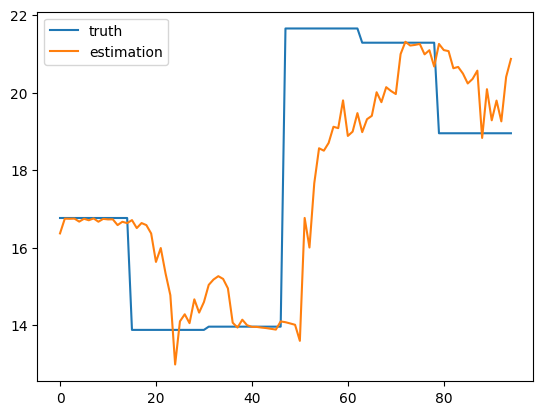

In [6]:
import matplotlib.pyplot as plt
plt.plot(gt_hist, label="truth")
plt.plot(est_hist, label="estimation")
plt.legend()
plt.show()

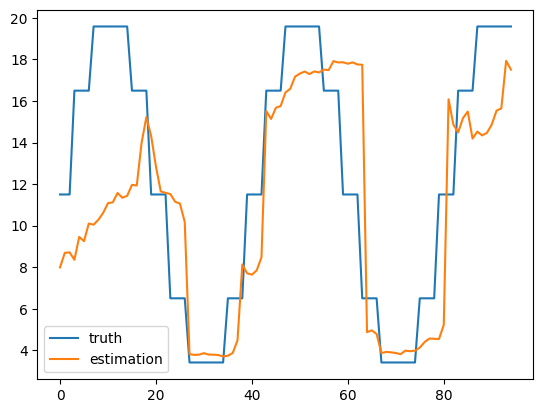

In [19]:
import matplotlib.pyplot as plt
plt.plot(gt_hist, label="truth")
plt.plot(est_hist, label="estimation")
plt.legend()
plt.show()


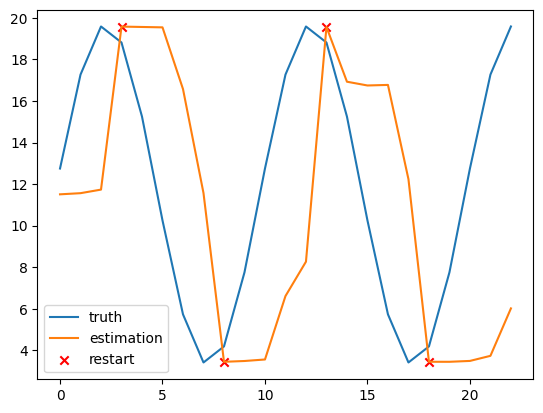

In [6]:
import matplotlib.pyplot as plt
import numpy as np

gt = np.array(gt_hist)
est = np.array(est_hist)
restart = np.array(restart_hist, dtype=bool)

plt.plot(gt, label="truth")
plt.plot(est, label="estimation")

# 找到 restart 为 True 的索引
idx = np.where(restart)[0]

# 在这些点画红叉
plt.scatter(idx, est[idx], marker='x', color='red', label='restart')

plt.legend()
plt.show()

In [3]:
folder = "C:/Users/yxu59/files/winter2026/park/simulation/PhysicalData_v1"
stream = PhysicalStream(folder, mode=0)
emulator = PlantEmulator()
emulator.return_std = False

rmse_static_hist = []
for X,Y,theta in stream:
    y_static = emulator.predict(X, np.array([11.5]))
    rmse = np.sqrt(((y_static - Y)**2).mean())
    rmse_static_hist.append(rmse)

    

NameError: name 'PlantEmulator' is not defined

In [22]:
rmse_static_hist = np.array(rmse_static_hist)
np.mean(rmse_static_hist)


np.float64(56.02174801523474)

In [29]:
(np.array(est).reshape(-1,1)-np.array(gt).reshape(-1,1)).shape

(239, 1)

In [32]:
np.mean(np.abs((np.array(est).reshape(-1,1)-np.array(gt).reshape(-1,1)))), np.mean(np.abs(np.array([11.5])-np.array(gt)))

(np.float64(2.78576548659229), np.float64(5.517270842035024))

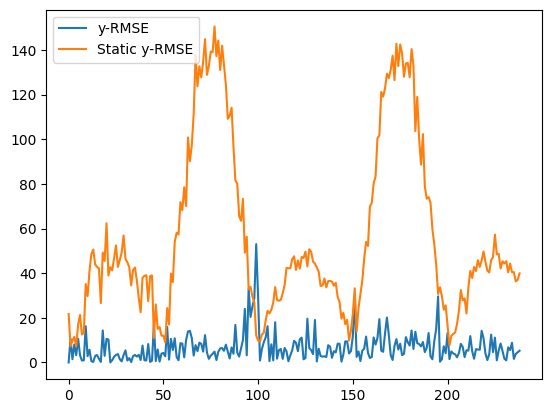

In [24]:
plt.plot(rmse_hist, label="y-RMSE")
plt.plot(rmse_static_hist, label="Static y-RMSE")
plt.legend()
plt.show()


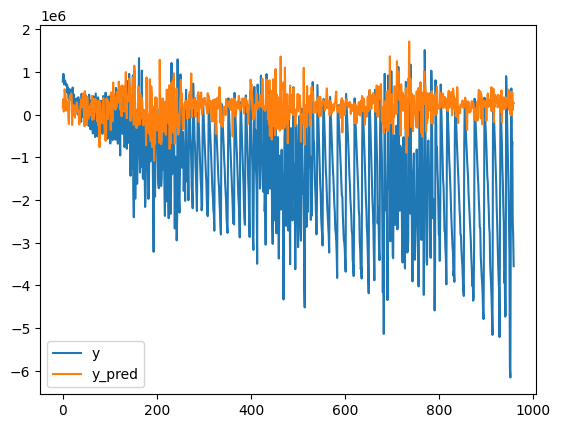

In [12]:
y_hist, y_pred_hist = [], []
for X,Y,theta in stream:
    # print(X, theta)
    y_pred, y_std = emulator.predict(X, np.array([theta]))
    # print(y_pred.shape, Y.shape)
    y_pred = y_pred.numpy().item()
    y_hist.append(Y)
    y_pred_hist.append(y_pred)
plt.plot(y_hist, label="y")
plt.plot(y_pred_hist, label="y_pred")
plt.legend()
plt.show()

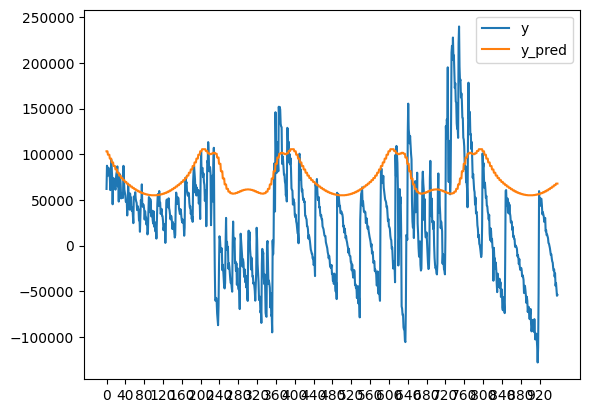

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(y_hist, label="y")
plt.plot(y_pred_hist, label="y_pred")

n = len(y_hist)
step = 40   # 每50个点一个刻度（自己调）
plt.xticks(np.arange(0, n, step))

plt.legend()
plt.show()

## check v3 data and NN surrogate

In [8]:
folder = r"C:\Users\yxu59\files\winter2026\park\simulation\PhysicalData_v3"

# mode=0: strictly in t order
# s0 = StreamClass(0, folder)
# X, y, theta = s0.next(8)
# print("mode0 batch:", X.shape, y.shape, theta.shape, "theta(sec) sample:", theta[:2])

# mode=1: with jumps
jp = JumpPlan(
    max_jumps=5,           # ~4-5 jumps for ~1200 pts
    min_gap_theta=500.0,   # seconds; tune
    min_interval=180,
    max_interval=320,
    min_jump_span=40,
    seed=7
)
s1 = StreamClass(0, folder, jump_plan=jp)
# s1 = StreamClass(0, folder)
from calib.emulator import Emulator
class PlantEmulatorNN(Emulator):
    def __init__(self):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        nnwrap = NNModelTorch(input_dim=6).load("C:/Users/yxu59/files/autumn2025/park/codes/plant simulation/nn_model_revenue.pkl", device=device)
        self.computer_model = nnwrap
        # self.return_std = True

    def predict(self, x, theta):
        mu_eta = self.computer_model.predict(x, theta)
        mu_eta = torch.from_numpy(mu_eta)
        var_eta = torch.zeros_like(mu_eta)
        return mu_eta, var_eta

cfg = CalibrationConfig()
cfg.bocpd.bocpd_mode = "restart"
cfg.bocpd.use_restart = True
cfg.model.use_discrepancy = False

def prior_sampler(N):
    return torch.rand(N, 1)*18+3

emulatorNN = PlantEmulatorNN()

calib = OnlineBayesCalibrator(cfg, emulatorNN, prior_sampler)

from collections import deque
import numpy as np
import warnings
warnings.filterwarnings("ignore")

gt_hist, est_hist = [], []
rmse_hist, comp_rmse_hist = [0], [0]
restart_hist = []
idx = 0
from tqdm import tqdm
# for k in range(10):
for k in tqdm(range(200)):
    Xb, yb, thb = s1.next(4)
    newX = torch.tensor(Xb)
    theta = torch.tensor(thb)
    newY = torch.tensor(yb)
    # X_torch, Y_torch = X_torch[:2,:], Y_torch[:2]
    rec = calib.step_batch(newX, newY, verbose=False)
    mean_theta, var_theta, lo_theta, hi_theta = calib._aggregate_particles(0.9)
    gt_hist.append(theta.mean().item()/60)
    est_hist.append(mean_theta.item())

    if idx > 0: 
        pred = calib.predict_batch(newX)
        rmse_hist.append(torch.sqrt(((pred["mu"] - newY)**2).mean()))
        pred_comp = calib.predict_complete(newX, newY)
        comp_rmse_hist.append(torch.sqrt(((pred_comp["mu_sim"] - newY)**2).mean()))
    idx += 1

    restart_hist.append(rec["did_restart"])
    # print(theta, mean_theta)
    # if idx > 100:
    #     break

✅ Using R-BOCPD mode: Algorithm-2


  0%|          | 0/200 [00:00<?, ?it/s]

  7%|▋         | 14/200 [00:30<08:11,  2.64s/it]


[DEBUG BEFORE RESTART] t=60, r_old=0, s_star=56
  p_anchor=0.000000, best_other_mass=0.995000, p_cp=0.005000
  Top-5 experts BEFORE restart:
  theta_test=energy stat=0.0 pass=True
    Expert[0] rl=4, mass=0.995000, theta_mean=[17.98315932]
    Expert[1] rl=0, mass=0.005000, theta_mean=[11.94913403]
    Expert[2] rl=60, mass=0.000000, theta_mean=[15.22058579]
    Expert[3] rl=56, mass=0.000000, theta_mean=[15.19564226]
    Expert[4] rl=52, mass=0.000000, theta_mean=[15.33231399]
--------------------------------------------------------



  8%|▊         | 15/200 [00:31<06:05,  1.98s/it]

...


[DEBUG BEFORE RESTART] t=104, r_old=76, s_star=88
  p_anchor=0.000000, best_other_mass=0.995283, p_cp=0.004717
  Top-5 experts BEFORE restart:
  theta_test=energy stat=0.0 pass=True
    Expert[0] rl=16, mass=0.995283, theta_mean=[19.90824025]
    Expert[1] rl=0, mass=0.004717, theta_mean=[12.08927267]
    Expert[2] rl=28, mass=0.000000, theta_mean=[19.91322569]
    Expert[3] rl=24, mass=0.000000, theta_mean=[19.91559699]
    Expert[4] rl=4, mass=0.000000, theta_mean=[19.91975536]
--------------------------------------------------------



 13%|█▎        | 26/200 [00:46<04:07,  1.42s/it]

[R-BOCPD][batch] Restart ending at t=104: mode=ALGO2 r←t+1, r_old=76, r_new=104, s_star=88, p_anchor=0, p_cp=0.004717
  expert#0: rl=0, start=104, mass=1, log_ump=-5385554301.813316


 44%|████▍     | 89/200 [04:58<06:12,  3.36s/it]


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
plt.plot(np.array(gt_hist), label="truth")
plt.plot(est_hist, label="nodiscrepancy estimation")
plt.legend()
plt.show()

([710.0194184451852,
  741.9734565969678,
  773.722379259976,
  805.1408879411615,
  836.1049881405113],
 [11.533965988214339,
  11.866642815249694,
  11.61215738459078,
  13.265125077737077,
  12.980376169644192])

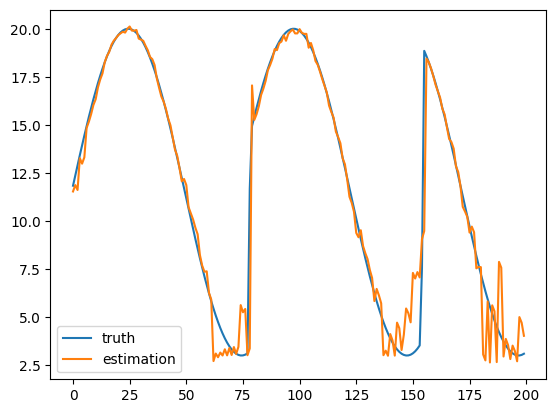

In [7]:
plt.plot(np.array(gt_hist)/60, label="truth")
plt.plot(est_hist, label="estimation")
plt.legend()
plt.show()


## Gpytorch surrogate is so bad

In [27]:
folder = r"C:\Users\yxu59\files\winter2026\park\simulation\PhysicalData_v3_bad"

# mode=0: strictly in t order
s0 = StreamClass(0, folder)
# X, y, theta = s0.next(8)
# print("mode0 batch:", X.shape, y.shape, theta.shape, "theta(sec) sample:", theta[:2])

# mode=1: with jumps
jp = JumpPlan(
    max_jumps=5,           # ~4-5 jumps for ~1200 pts
    min_gap_theta=500.0,   # seconds; tune
    min_interval=180,
    max_interval=320,
    min_jump_span=40,
    seed=7
)
# s1 = StreamClass(0, folder, jump_plan=jp)
s1 = StreamClass(0, folder)
from calib.emulator import Emulator
class PlantEmulatorNN(Emulator):
    def __init__(self):
        device = "cuda" if torch.cuda.is_available() else "cpu"
        gpwrap = GPModelTorch.load("C:\\Users\\yxu59\\files\\winter2026\\park\\simulation\\ComputerData_v3\\gpytorch_gp_model_revenue.pkl")
        self.computer_model = gpwrap
        # self.return_std = True

    def predict(self, x, theta):
        mu_eta, std_eta = self.computer_model.predict(x, theta)
        mu_eta = torch.from_numpy(mu_eta)
        var_eta = torch.from_numpy(std_eta**2)
        return mu_eta, var_eta

cfg = CalibrationConfig()
cfg.bocpd.bocpd_mode = "restart"
cfg.bocpd.use_restart = True
cfg.model.use_discrepancy = True

def prior_sampler(N):
    return torch.rand(N, 1)*18+3

emulatorNN = PlantEmulatorNN()

calib = OnlineBayesCalibrator(cfg, emulatorNN, prior_sampler)

from collections import deque
import numpy as np
import warnings
warnings.filterwarnings("ignore")

gt_hist, est_hist = [], []
rmse_hist, comp_rmse_hist = [0], [0]
restart_hist = []
idx = 0
from tqdm import tqdm
# for k in range(10):
for k in tqdm(range(60)):
    Xb, yb, thb = s1.next(4)
    newX = torch.tensor(Xb)
    theta = torch.tensor(thb)
    newY = torch.tensor(yb)
    # X_torch, Y_torch = X_torch[:2,:], Y_torch[:2]
    rec = calib.step_batch(newX, newY, verbose=False)
    mean_theta, var_theta, lo_theta, hi_theta = calib._aggregate_particles(0.9)
    gt_hist.append(theta.mean().item())
    est_hist.append(mean_theta.item())

    if idx > 0: 
        pred = calib.predict_batch(newX)
        rmse_hist.append(torch.sqrt(((pred["mu"] - newY)**2).mean()))
        pred_comp = calib.predict_complete(newX, newY)
        comp_rmse_hist.append(torch.sqrt(((pred_comp["mu_sim"] - newY)**2).mean()))
    idx += 1

    restart_hist.append(rec["did_restart"])
    # print(theta, mean_theta)
    # if idx > 100:
    #     break


✅ Using R-BOCPD mode: Algorithm-2


  8%|▊         | 5/60 [00:05<01:05,  1.19s/it]


[DEBUG BEFORE RESTART] t=24, r_old=0, s_star=12
  p_anchor=0.000739, best_other_mass=0.932338, p_cp=0.004813
  Top-5 experts BEFORE restart:
  theta_test=energy stat=0.0 pass=True
    Expert[0] rl=12, mass=0.932338, theta_mean=[15.52861329]
    Expert[1] rl=8, mass=0.062105, theta_mean=[15.40371607]
    Expert[2] rl=0, mass=0.004813, theta_mean=[12.24879428]
    Expert[3] rl=24, mass=0.000739, theta_mean=[15.55727801]
    Expert[4] rl=20, mass=0.000004, theta_mean=[15.60485288]
--------------------------------------------------------



 10%|█         | 6/60 [00:05<00:47,  1.13it/s]

[R-BOCPD][batch] Restart ending at t=24: mode=ALGO2 r←t+1, r_old=0, r_new=24, s_star=12, p_anchor=0.0007394, p_cp=0.004813
  expert#0: rl=0, start=24, mass=1, log_ump=-67.56764602664948


100%|██████████| 60/60 [01:52<00:00,  1.88s/it]


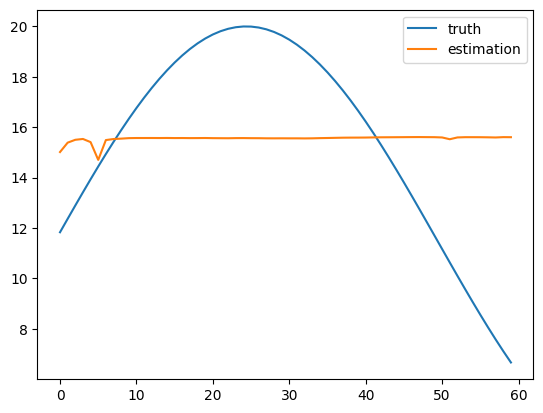

In [28]:
plt.plot(gt_hist, label="truth")
plt.plot(est_hist, label="estimation")
plt.legend()
plt.show()


## Data standarization

In [5]:
import dataclasses
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# =========================
# 1) y transform: signed log1p
# =========================
@dataclasses.dataclass
class SignedLog1pTransformer:
    c: float = None

    def fit(self, y: np.ndarray):
        y = np.asarray(y).reshape(-1)
        abs_y = np.abs(y)
        c = np.median(abs_y[abs_y > 0]) if np.any(abs_y > 0) else 1.0
        self.c = float(c)
        return self

    def transform(self, y: np.ndarray) -> np.ndarray:
        if self.c is None:
            raise ValueError("SignedLog1pTransformer not fitted")
        y = np.asarray(y).reshape(-1)
        return np.sign(y) * np.log1p(np.abs(y) / self.c)

    def inverse_transform(self, z: np.ndarray) -> np.ndarray:
        if self.c is None:
            raise ValueError("SignedLog1pTransformer not fitted")
        z = np.asarray(z).reshape(-1)
        return np.sign(z) * self.c * np.expm1(np.abs(z))


# =========================
# 2) GlobalTransform: shared by NN + PF/BOCPD
#    X_full = [W,R,M1,M2,Q,theta]
#    y_raw -> y_t(signedlog) -> y_s(zscore)
# =========================
@dataclasses.dataclass
class GlobalTransform:
    x_scaler: StandardScaler = dataclasses.field(default_factory=StandardScaler)
    y_scaler: StandardScaler = dataclasses.field(default_factory=StandardScaler)
    y_transform: SignedLog1pTransformer = dataclasses.field(default_factory=SignedLog1pTransformer)
    fitted: bool = False

    def fit(self, X_base: np.ndarray, theta: np.ndarray, y_raw: np.ndarray):
        """
        Fit on TRAIN split only. Do NOT fit on whole stream to avoid leakage.
        """
        X_base = np.asarray(X_base)
        theta = np.asarray(theta).reshape(-1)
        y_raw = np.asarray(y_raw).reshape(-1)

        if X_base.shape[0] != theta.shape[0] or X_base.shape[0] != y_raw.shape[0]:
            raise ValueError("fit: X_base/theta/y length mismatch")

        # build X_full(6)
        X_full = np.column_stack([X_base, theta])

        # y: signedlog then zscore
        self.y_transform.fit(y_raw)
        y_t = self.y_transform.transform(y_raw)

        self.x_scaler.fit(X_full)
        self.y_scaler.fit(y_t.reshape(-1, 1))

        self.fitted = True
        return self

    # ---- X transforms ----
    def transform_X_full(self, X_full: np.ndarray) -> np.ndarray:
        if not self.fitted:
            raise ValueError("GlobalTransform not fitted")
        return self.x_scaler.transform(np.asarray(X_full)).astype(np.float32)

    def make_X_full(self, X_base: np.ndarray, theta: np.ndarray) -> np.ndarray:
        X_base = np.asarray(X_base)
        theta = np.asarray(theta).reshape(-1)
        if theta.size == 1:
            theta = np.repeat(theta.item(), X_base.shape[0])
        if theta.size != X_base.shape[0]:
            raise ValueError("make_X_full: theta must be scalar or length N")
        return np.column_stack([X_base, theta])

    # ---- y transforms ----
    def y_raw_to_t(self, y_raw: np.ndarray) -> np.ndarray:
        if not self.fitted:
            raise ValueError("GlobalTransform not fitted")
        return self.y_transform.transform(y_raw)

    def y_t_to_s(self, y_t: np.ndarray) -> np.ndarray:
        if not self.fitted:
            raise ValueError("GlobalTransform not fitted")
        return self.y_scaler.transform(np.asarray(y_t).reshape(-1, 1)).ravel()

    def y_raw_to_s(self, y_raw: np.ndarray) -> np.ndarray:
        y_t = self.y_raw_to_t(y_raw)
        return self.y_t_to_s(y_t)

    def y_s_to_t(self, y_s: np.ndarray) -> np.ndarray:
        if not self.fitted:
            raise ValueError("GlobalTransform not fitted")
        return self.y_scaler.inverse_transform(np.asarray(y_s).reshape(-1, 1)).ravel()

    def y_t_to_raw(self, y_t: np.ndarray) -> np.ndarray:
        if not self.fitted:
            raise ValueError("GlobalTransform not fitted")
        return self.y_transform.inverse_transform(y_t)

    def y_s_to_raw(self, y_s: np.ndarray) -> np.ndarray:
        y_t = self.y_s_to_t(y_s)
        return self.y_t_to_raw(y_t)


# =========================
# 3) MLP
# =========================
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden=(128, 128, 64), dropout=0.0):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# =========================
# 4) NNModelTorchZ: train/predict in y_s space
#    - no inverse in predict
# =========================
@dataclasses.dataclass
class NNModelTorchZ:
    input_dim: int = 6
    device: str = None
    transform: GlobalTransform = None  # MUST be fitted outside (on train split)

    model: nn.Module = None

    def _get_device(self):
        if self.device is not None:
            return torch.device(self.device)
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def fit(
        self,
        X_base: np.ndarray,
        theta: np.ndarray,
        y_raw: np.ndarray,
        val_frac: float = 0.10,
        batch_size: int = 128,
        lr: float = 1e-3,
        epochs: int = 200,
        hidden=(128, 128, 64),
        dropout: float = 0.0,
        weight_decay: float = 1e-6,
        seed: int = 0,
        verbose_every: int = 20,
    ):
        if self.transform is None or not self.transform.fitted:
            raise ValueError("NNModelTorchZ.fit requires a fitted GlobalTransform (fit it on train split first).")

        rng = np.random.default_rng(seed)
        dev = self._get_device()

        X_base = np.asarray(X_base)
        theta = np.asarray(theta).reshape(-1)
        y_raw = np.asarray(y_raw).reshape(-1)

        # build X_full and transform to X_s
        X_full = self.transform.make_X_full(X_base, theta)
        X_s = self.transform.transform_X_full(X_full)

        # y_raw -> y_s
        y_s = self.transform.y_raw_to_s(y_raw).astype(np.float32)

        # split (NOTE: transform already fitted; we only split for early stopping)
        X_tr, X_va, y_tr, y_va = train_test_split(
            X_s, y_s, test_size=val_frac, random_state=seed, shuffle=True
        )

        X_tr_t = torch.from_numpy(X_tr).to(dev)
        y_tr_t = torch.from_numpy(y_tr).to(dev)
        X_va_t = torch.from_numpy(X_va).to(dev)
        y_va_t = torch.from_numpy(y_va).to(dev)

        train_loader = DataLoader(
            TensorDataset(X_tr_t, y_tr_t),
            batch_size=batch_size,
            shuffle=True,
            drop_last=False
        )

        self.model = MLP(self.input_dim, hidden=hidden, dropout=dropout).to(dev)

        opt = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = nn.MSELoss()

        best_val = float("inf")
        best_state = None
        patience = 30
        bad = 0

        for ep in range(1, epochs + 1):
            self.model.train()
            for xb, yb in train_loader:
                opt.zero_grad()
                pred = self.model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()

            self.model.eval()
            with torch.no_grad():
                val_pred = self.model(X_va_t)
                val_loss = loss_fn(val_pred, y_va_t).item()

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if verbose_every and ep % verbose_every == 0:
                print(f"epoch {ep:4d} | val_mse(y_s)={val_loss:.6f} | best={best_val:.6f}")

            if bad >= patience:
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)

        # Report RMSE in RAW space (by inverse transform)
        self.model.eval()
        with torch.no_grad():
            y_va_pred_s = self.model(X_va_t).detach().cpu().numpy()

        y_va_pred_raw = self.transform.y_s_to_raw(y_va_pred_s)
        y_va_raw = self.transform.y_s_to_raw(y_va)

        rmse_raw = float(np.sqrt(np.mean((y_va_pred_raw - y_va_raw) ** 2)))
        mae_raw = float(np.mean(np.abs(y_va_pred_raw - y_va_raw)))

        print("\nNN validation (RAW y space)")
        print("RMSE:", rmse_raw)
        print("MAE :", mae_raw)

        return self

    def predict_y_s(self, X_base: np.ndarray, theta: np.ndarray) -> np.ndarray:
        """Return mean prediction in y_s space."""
        if self.model is None:
            raise ValueError("NN model not fitted/loaded.")
        if self.transform is None or not self.transform.fitted:
            raise ValueError("Need fitted GlobalTransform")

        dev = self._get_device()
        X_base = np.atleast_2d(X_base)
        X_full = self.transform.make_X_full(X_base, theta)
        X_s = self.transform.transform_X_full(X_full)

        Xt = torch.from_numpy(X_s).to(dev)
        self.model.eval()
        with torch.no_grad():
            y_s = self.model(Xt).detach().cpu().numpy()
        return y_s

    def save(self, path: str):
        if self.model is None:
            raise ValueError("Nothing to save.")
        if self.transform is None or not self.transform.fitted:
            raise ValueError("Need fitted GlobalTransform to save.")

        bundle = {
            "state_dict": self.model.state_dict(),
            "x_scaler": self.transform.x_scaler,
            "y_scaler": self.transform.y_scaler,
            "c": self.transform.y_transform.c,
            "meta": {"input_dim": self.input_dim,
                     "hidden": [m.out_features for m in self.model.net if isinstance(m, nn.Linear)][:-1]},
        }
        joblib.dump(bundle, path)

    @classmethod
    def load(cls, path: str, device: str = None):
        bundle = joblib.load(path)
        input_dim = int(bundle["meta"].get("input_dim", 6))
        obj = cls(input_dim=input_dim, device=device)

        # rebuild transform from saved scalers
        gt = GlobalTransform()
        gt.x_scaler = bundle["x_scaler"]
        gt.y_scaler = bundle["y_scaler"]
        gt.y_transform.c = float(bundle["c"])
        gt.fitted = True
        obj.transform = gt

        hidden = bundle["meta"].get("hidden", [128, 128, 64])
        obj.model = MLP(input_dim, hidden=tuple(hidden), dropout=0.0).to(obj._get_device())
        obj.model.load_state_dict(bundle["state_dict"])
        obj.model.eval()
        return obj


# =========================
# 5) Emulator wrapper for calibrator (works in y_s space)
# =========================
@dataclasses.dataclass
class PlantEmulatorNNZ:
    nnz: NNModelTorchZ  # trained in y_s

    def predict(self, X_base: np.ndarray, theta: np.ndarray) -> np.ndarray:
        """
        Return mu in y_s space.
        X_base: (N,5)
        theta : scalar or (N,)
        """
        mu_eta = torch.from_numpy(self.nnz.predict_y_s(X_base, theta))
        std_eta = torch.zeros_like(mu_eta)
        return mu_eta, std_eta


# =========================
# 6) Optional: raw-RMSE helper inside PF loop
# =========================
def rmse_raw_from_mu_s(transform: GlobalTransform, mu_s_torch: torch.Tensor, y_raw_torch: torch.Tensor) -> torch.Tensor:
    mu_s = mu_s_torch.detach().cpu().numpy()
    mu_raw = transform.y_s_to_raw(mu_s)
    mu_raw_t = torch.from_numpy(mu_raw).to(y_raw_torch.device).to(torch.float64)
    return torch.sqrt(((mu_raw_t - y_raw_torch.to(torch.float64)) ** 2).mean())


# =========================
# 7) Optional: convert simulated samples (in y_s) to raw and compute MC-CRPS
#    (only if you have y_sim samples)
# =========================
def crps_mc_from_samples_raw(transform: GlobalTransform, y_sim_s: np.ndarray, y_obs_raw: np.ndarray) -> float:
    """
    y_sim_s: (S,) or (S,N) samples in y_s space
    y_obs_raw: (N,) raw observations
    Returns MC estimate of CRPS in raw space per point averaged.
    """
    y_sim_s = np.asarray(y_sim_s)
    y_obs_raw = np.asarray(y_obs_raw).reshape(-1)

    if y_sim_s.ndim == 1:
        y_sim_s = y_sim_s[:, None]  # (S,1)

    S, N = y_sim_s.shape
    # inverse to raw
    y_sim_raw = np.stack([transform.y_s_to_raw(y_sim_s[s]) for s in range(S)], axis=0)  # (S,N)

    # MC CRPS: E|X-y| - 0.5 E|X-X'|
    term1 = np.mean(np.abs(y_sim_raw - y_obs_raw[None, :]), axis=0)  # (N,)
    # approximate second term with pairwise difference via two-sample trick
    # draw another independent sample set by permutation
    perm = np.random.permutation(S)
    term2 = 0.5 * np.mean(np.abs(y_sim_raw - y_sim_raw[perm]), axis=0)
    return float(np.mean(term1 - term2))

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

data = np.load("C:/Users/yxu59/files/winter2026/park/simulation/ComputerData_v3/factory_aggregated.npz", allow_pickle=True)
X_base = data["X"]          # (N,5)
y_raw  = data["y"]          # (N,)
theta  = data["theta"]      # (N,)

# split first (avoid leakage)
X_tr, X_te, y_tr, y_te, th_tr, th_te = train_test_split(X_base, y_raw, theta, test_size=0.2, random_state=0, shuffle=True)

gt = GlobalTransform().fit(X_tr, th_tr, y_tr)   # fit ONLY on train

In [6]:
X_tr[:5]

array([[ 11.,  92.,   3.,   2., 102.],
       [ 30.,  96.,   2.,   1.,  68.],
       [ 23., 146.,   3.,   1.,  86.],
       [ 15., 109.,   1.,   1., 101.],
       [ 13.,  89.,   1.,   1.,  55.]])

In [4]:
nnz = NNModelTorchZ(input_dim=6, transform=gt).fit(X_tr, th_tr, y_tr, epochs=200)
nnz.save("nnz.bundle.joblib")

epoch   20 | val_mse(y_s)=0.111958 | best=0.101794
epoch   40 | val_mse(y_s)=0.047952 | best=0.047952
epoch   60 | val_mse(y_s)=0.031575 | best=0.029392
epoch   80 | val_mse(y_s)=0.023777 | best=0.021988
epoch  100 | val_mse(y_s)=0.021639 | best=0.019516
epoch  120 | val_mse(y_s)=0.020557 | best=0.018029
epoch  140 | val_mse(y_s)=0.019306 | best=0.018029

NN validation (RAW y space)
RMSE: 79540.125
MAE : 36020.54296875


In [ ]:
emu = PlantEmulatorNNZ(nnz)   # emulator outputs mu_s

folder = r"C:\Users\yxu59\files\winter2026\park\simulation\PhysicalData_v3"

# mode=0: strictly in t order
# s0 = StreamClass(0, folder)
# X, y, theta = s0.next(8)
# print("mode0 batch:", X.shape, y.shape, theta.shape, "theta(sec) sample:", theta[:2])

# mode=1: with jumps
jp = JumpPlan(
    max_jumps=5,           # ~4-5 jumps for ~1200 pts
    min_gap_theta=500.0,   # seconds; tune
    min_interval=180,
    max_interval=320,
    min_jump_span=40,
    seed=7
)
s1 = StreamClass(0, folder)
# s1 = StreamClass(0, folder)
from calib.emulator import Emulator
# class PlantEmulatorNN(Emulator):
#     def __init__(self):
#         device = "cuda" if torch.cuda.is_available() else "cpu"
#         nnwrap = NNModelTorch(input_dim=6).load("C:/Users/yxu59/files/autumn2025/park/codes/plant simulation/nn_model_revenue.pkl", device=device)
#         self.computer_model = nnwrap
#         # self.return_std = True

#     def predict(self, x, theta):
#         mu_eta = self.computer_model.predict(x, theta)
#         mu_eta = torch.from_numpy(mu_eta)
#         var_eta = torch.zeros_like(mu_eta)
#         return mu_eta, var_eta

cfg = CalibrationConfig()
cfg.bocpd.bocpd_mode = "restart"
cfg.bocpd.use_restart = True
cfg.model.use_discrepancy = True

# emulatorNN = PlantEmulatorNN()

calib = OnlineBayesCalibrator(cfg, emu, prior_sampler)

from collections import deque
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch

def transform_batch_X(gt, Xb, thb):
    """
    Xb: (B,5) raw
    thb: (B,) raw theta (minutes)
    return: X_s_torch (B,6) float64 in standardized space
    """
    X_full = gt.make_X_full(Xb, thb)            # (B,6) raw
    X_s = gt.transform_X_full(X_full)           # (B,6) float32
    return torch.tensor(X_s, dtype=torch.float64)

def transform_batch_y(gt, yb):
    """
    yb: (B,) raw revenue
    return: y_s_torch (B,) float64
    """
    y_s = gt.y_raw_to_s(yb).astype(np.float64)  # (B,)
    return torch.tensor(y_s, dtype=torch.float64)

theta_mu = float(gt.x_scaler.mean_[5])
theta_sd = float(gt.x_scaler.scale_[5])

def theta_raw_to_s(theta_raw):
    return (theta_raw - theta_mu) / theta_sd

def theta_s_to_raw(theta_s):
    return theta_s * theta_sd + theta_mu

a_raw, b_raw = 180, 1260
a_s = (a_raw - theta_mu) / theta_sd
b_s = (b_raw - theta_mu) / theta_sd

def prior_sampler(N):
    return torch.rand(N, 1) * (b_s - a_s) + a_s   # theta_s

gt_hist, est_hist = [], []
rmse_hist, comp_rmse_hist = [0], [0]
restart_hist = []
idx = 0
from tqdm import tqdm
# for k in range(10):
for k in tqdm(range(200)):
    Xb, yb, thb = s1.next(4)
    # newX = torch.tensor(Xb)
    # theta = torch.tensor(thb)
    # newY = torch.tensor(yb)
    y_raw_t = torch.tensor(yb, dtype=torch.float64)
    theta_raw_t = torch.tensor(thb, dtype=torch.float64)

    # 2) standardized space inputs for PF/BOCPD
    newX = transform_batch_X(gt, Xb, thb)    # (B,6) standardized
    newY = transform_batch_y(gt, yb)
    # X_torch, Y_torch = X_torch[:2,:], Y_torch[:2]
    rec = calib.step_batch(newX, newY, verbose=False)
    mean_theta, var_theta, lo_theta, hi_theta = calib._aggregate_particles(0.9)
    gt_hist.append(theta.mean().item())
    mean_theta_raw = theta_s_to_raw(mean_theta.item())
    var_theta_raw = var_theta * (theta_sd ** 2)
    print(gt_hist[-1]/60, mean_theta_raw/60)

    theta_hist.append(mean_theta_raw)
    theta_var_hist.append(var_theta_raw)

    if k > 0:
        pred = calib.predict_batch(newX)     # 现在 pred["mu"] 必须是在 y_s 空间
        # RMSE in raw space: mu_s -> raw
        mu_s = pred["mu"].detach().cpu().numpy()
        mu_raw = gt.y_s_to_raw(mu_s)
        mu_raw_t = torch.tensor(mu_raw, dtype=torch.float64)
        rmse_hist.append(torch.sqrt(((mu_raw_t - y_raw_t) ** 2).mean()))

        # 你的 complete 也要用 standardized 的 newX/newY
        pred_comp = calib.predict_complete(newX, newY)
        report_sub_hist = (
            pred_comp["crps_sim"].item(),
            pred_comp["experts_logpred"],
            pred_comp["var_sim"],
        )
        comp_rmse_hist.append(report_sub_hist)


    restart_hist.append(rec["did_restart"])
    # print(theta, mean_theta)
    # if idx > 100:
    #     break

In [5]:
import dataclasses
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
from tqdm import tqdm

# =========================
# 1) y transform: signed log1p
# =========================
@dataclasses.dataclass
class SignedLog1pTransformer:
    c: float = None

    def fit(self, y: np.ndarray):
        y = np.asarray(y).reshape(-1)
        abs_y = np.abs(y)
        c = np.median(abs_y[abs_y > 0]) if np.any(abs_y > 0) else 1.0
        self.c = float(c)
        return self

    def transform(self, y: np.ndarray) -> np.ndarray:
        if self.c is None:
            raise ValueError("SignedLog1pTransformer not fitted")
        y = np.asarray(y).reshape(-1)
        return np.sign(y) * np.log1p(np.abs(y) / self.c)

    def inverse_transform(self, z: np.ndarray) -> np.ndarray:
        if self.c is None:
            raise ValueError("SignedLog1pTransformer not fitted")
        z = np.asarray(z).reshape(-1)
        return np.sign(z) * self.c * np.expm1(np.abs(z))


# =========================
# 2) GlobalTransformSep
#    - X_base (5) and theta (1) are standardized SEPARATELY
#    - y_raw -> y_t(signedlog) -> y_s(zscore)
# =========================
@dataclasses.dataclass
class GlobalTransformSep:
    x_base_scaler: StandardScaler = dataclasses.field(default_factory=StandardScaler)   # 5-d
    theta_scaler: StandardScaler = dataclasses.field(default_factory=StandardScaler)   # 1-d
    y_scaler: StandardScaler = dataclasses.field(default_factory=StandardScaler)       # 1-d (on y_t)
    y_transform: SignedLog1pTransformer = dataclasses.field(default_factory=SignedLog1pTransformer)
    fitted: bool = False

    def fit(self, X_base: np.ndarray, theta_raw: np.ndarray, y_raw: np.ndarray):
        X_base = np.asarray(X_base)
        theta_raw = np.asarray(theta_raw).reshape(-1, 1)  # minutes
        y_raw = np.asarray(y_raw).reshape(-1)

        if X_base.shape[0] != theta_raw.shape[0] or X_base.shape[0] != y_raw.shape[0]:
            raise ValueError("fit: length mismatch")

        # fit x scalers
        self.x_base_scaler.fit(X_base)
        self.theta_scaler.fit(theta_raw)

        # fit y transform + y scaler
        self.y_transform.fit(y_raw)
        y_t = self.y_transform.transform(y_raw)
        self.y_scaler.fit(y_t.reshape(-1, 1))

        self.fitted = True
        return self

    # ---- X_base ----
    def X_base_to_s(self, X_base: np.ndarray) -> np.ndarray:
        if not self.fitted: raise ValueError("GlobalTransformSep not fitted")
        return self.x_base_scaler.transform(np.asarray(X_base)).astype(np.float32)

    # ---- theta ----
    def theta_raw_to_s(self, theta_raw: np.ndarray) -> np.ndarray:
        if not self.fitted: raise ValueError("GlobalTransformSep not fitted")
        th = np.asarray(theta_raw).reshape(-1, 1)
        return self.theta_scaler.transform(th).ravel().astype(np.float32)

    def theta_s_to_raw(self, theta_s: np.ndarray) -> np.ndarray:
        if not self.fitted: raise ValueError("GlobalTransformSep not fitted")
        ths = np.asarray(theta_s).reshape(-1, 1)
        return self.theta_scaler.inverse_transform(ths).ravel()

    @property
    def theta_mu(self) -> float:
        return float(self.theta_scaler.mean_[0])

    @property
    def theta_sd(self) -> float:
        return float(self.theta_scaler.scale_[0])

    # ---- y ----
    def y_raw_to_s(self, y_raw: np.ndarray) -> np.ndarray:
        if not self.fitted: raise ValueError("GlobalTransformSep not fitted")
        y_raw = np.asarray(y_raw).reshape(-1)
        y_t = self.y_transform.transform(y_raw)
        y_s = self.y_scaler.transform(y_t.reshape(-1, 1)).ravel()
        return y_s.astype(np.float32)

    def y_s_to_raw(self, y_s: np.ndarray) -> np.ndarray:
        if not self.fitted: raise ValueError("GlobalTransformSep not fitted")
        y_s = np.asarray(y_s).reshape(-1)
        y_t = self.y_scaler.inverse_transform(y_s.reshape(-1, 1)).ravel()
        y_raw = self.y_transform.inverse_transform(y_t)
        return y_raw


# =========================
# 3) MLP (input_dim=6: [x_base_s(5), theta_s(1)])
# =========================
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden=(128, 128, 64), dropout=0.0):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# =========================
# 4) NNModelTorchStd: train/predict in standardized space only
#    - inputs: X_full_s (B,6)
#    - outputs: y_s (B,)
# =========================
@dataclasses.dataclass
class NNModelTorchStd:
    input_dim: int = 6
    device: str = None
    model: nn.Module = None

    def _get_device(self):
        if self.device is not None:
            return torch.device(self.device)
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def fit(
        self,
        X_full_s: np.ndarray,    # (N,6) standardized
        y_s: np.ndarray,         # (N,) standardized
        val_frac: float = 0.10,
        batch_size: int = 128,
        lr: float = 1e-3,
        epochs: int = 200,
        hidden=(128, 128, 64),
        dropout: float = 0.0,
        weight_decay: float = 1e-6,
        seed: int = 0,
        verbose_every: int = 20,
    ):
        dev = self._get_device()

        X_full_s = np.asarray(X_full_s).astype(np.float32)
        y_s = np.asarray(y_s).astype(np.float32).reshape(-1)

        X_tr, X_va, y_tr, y_va = train_test_split(
            X_full_s, y_s, test_size=val_frac, random_state=seed, shuffle=True
        )

        X_tr_t = torch.from_numpy(X_tr).to(dev)
        y_tr_t = torch.from_numpy(y_tr).to(dev)
        X_va_t = torch.from_numpy(X_va).to(dev)
        y_va_t = torch.from_numpy(y_va).to(dev)

        train_loader = DataLoader(
            TensorDataset(X_tr_t, y_tr_t),
            batch_size=batch_size,
            shuffle=True,
            drop_last=False
        )

        self.model = MLP(self.input_dim, hidden=hidden, dropout=dropout).to(dev)
        opt = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        loss_fn = nn.MSELoss()

        best_val = float("inf")
        best_state = None
        patience = 30
        bad = 0

        for ep in range(1, epochs + 1):
            self.model.train()
            for xb, yb in train_loader:
                opt.zero_grad()
                pred = self.model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()

            self.model.eval()
            with torch.no_grad():
                val_pred = self.model(X_va_t)
                val_loss = loss_fn(val_pred, y_va_t).item()

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if verbose_every and ep % verbose_every == 0:
                print(f"epoch {ep:4d} | val_mse(y_s)={val_loss:.6f} | best={best_val:.6f}")

            if bad >= patience:
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)

        return self

    def predict_y_s_from_Xfull_s(self, X_full_s: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise ValueError("NN model not fitted/loaded.")
        dev = self._get_device()
        Xs = np.asarray(X_full_s).astype(np.float32)
        Xt = torch.from_numpy(Xs).to(dev)
        self.model.eval()
        with torch.no_grad():
            y_s = self.model(Xt).detach().cpu().numpy()
        return y_s

    def save(self, path: str):
        if self.model is None:
            raise ValueError("Nothing to save.")
        bundle = {"state_dict": self.model.state_dict()}
        joblib.dump(bundle, path)

    @classmethod
    def load(cls, path: str, device: str = None, input_dim: int = 6, hidden=(128,128,64)):
        bundle = joblib.load(path)
        obj = cls(input_dim=input_dim, device=device)
        obj.model = MLP(input_dim, hidden=tuple(hidden), dropout=0.0).to(obj._get_device())
        obj.model.load_state_dict(bundle["state_dict"])
        obj.model.eval()
        return obj


# =========================
# 5) Emulator in standardized space
#    predict(x_base_s (B,5), theta_s (N,1)) -> mu_s (N,B), var_s (N,B)
# =========================
class PlantEmulatorNNStd:
    def __init__(self, nn_std: NNModelTorchStd):
        self.nn = nn_std

    def predict(self, x, theta):
        """
        x: torch.Tensor
           - either (B,5) standardized X_base_s
        theta: torch.Tensor
           - either (N,1) theta_s particles
           - or (B,1) theta_s per-sample
        Returns:
           mu_s, var_s  (both torch.float64)
        """
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x)
        if not isinstance(theta, torch.Tensor):
            theta = torch.tensor(theta)

        x = x.to(torch.float64)
        theta = theta.to(torch.float64)

        # Case 1: theta is particle set (N,1), x is batch (B,5) -> output (N,B)
        if theta.ndim == 2 and theta.shape[1] == 1 and x.ndim == 2 and x.shape[1] == 5:
            N = theta.shape[0]
            B = x.shape[0]

            # Build X_full_s for all (particle, batch)
            x_rep = x.unsqueeze(0).repeat(N, 1, 1)              # (N,B,5)
            th_rep = theta.unsqueeze(1).repeat(1, B, 1)         # (N,B,1)
            X_full = torch.cat([x_rep, th_rep], dim=-1)         # (N,B,6)

            X_full_np = X_full.reshape(N*B, 6).cpu().numpy()
            mu_np = self.nn.predict_y_s_from_Xfull_s(X_full_np).reshape(N, B)
            mu = torch.tensor(mu_np, dtype=torch.float64, device=x.device).T
            var = torch.zeros_like(mu)
            return mu, var

        # Case 2: theta is per-sample (B,1) -> output (B,)
        if theta.ndim == 2 and theta.shape[1] == 1 and x.ndim == 2 and x.shape[1] == 5 and theta.shape[0] == x.shape[0]:
            X_full = torch.cat([x, theta], dim=1)               # (B,6)
            mu_np = self.nn.predict_y_s_from_Xfull_s(X_full.cpu().numpy())
            mu = torch.tensor(mu_np, dtype=torch.float64, device=x.device)
            var = torch.zeros_like(mu)
            return mu, var

        raise ValueError(f"Unsupported shapes: x={tuple(x.shape)}, theta={tuple(theta.shape)}")


# =========================
# 6) Helper: build standardized batches
# =========================
def batch_X_base_to_s(gt: GlobalTransformSep, Xb: np.ndarray) -> torch.Tensor:
    Xs = gt.X_base_to_s(Xb).astype(np.float64)      # (B,5)
    return torch.tensor(Xs, dtype=torch.float64)

def batch_y_to_s(gt: GlobalTransformSep, yb: np.ndarray) -> torch.Tensor:
    ys = gt.y_raw_to_s(yb).astype(np.float64)       # (B,)
    return torch.tensor(ys, dtype=torch.float64)


# =========================
# 7) MAIN: train + run PF loop
# =========================
# 7.1 load aggregated computer data
data = np.load(r"C:/Users/yxu59/files/winter2026/park/simulation/ComputerData_v3/factory_aggregated.npz", allow_pickle=True)
X_base = data["X"]       # (N,5)
y_raw  = data["y"]       # (N,)
theta_raw = data["theta"]  # (N,) minutes

# train/test split
X_tr, X_te, y_tr, y_te, th_tr, th_te = train_test_split(
    X_base, y_raw, theta_raw, test_size=0.2, random_state=0, shuffle=True
)

# fit transforms ONLY on train
gt = GlobalTransformSep().fit(X_tr, th_tr, y_tr)

# build standardized training set for NN: X_full_s = [X_base_s, theta_s]
X_tr_s = gt.X_base_to_s(X_tr)                           # (N,5)
th_tr_s = gt.theta_raw_to_s(th_tr).reshape(-1, 1)       # (N,1)
X_full_tr_s = np.concatenate([X_tr_s, th_tr_s], axis=1) # (N,6)
y_tr_s = gt.y_raw_to_s(y_tr)                            # (N,)

# train NN in standardized space
nn_std = NNModelTorchStd(input_dim=6).fit(X_full_tr_s, y_tr_s, epochs=200)
nn_std.save("nn_std.bundle.joblib")

# build standardized-space emulator
emu = PlantEmulatorNNStd(nn_std)

# ====== 你自己的 calibrator / stream / cfg ======
from calib.configs import CalibrationConfig
from calib.online_calibrator import OnlineBayesCalibrator

cfg = CalibrationConfig()
cfg.bocpd.bocpd_mode = "restart"
cfg.bocpd.use_restart = True
cfg.model.use_discrepancy = False

# IMPORTANT: prior_sampler returns theta_s (standardized!)
# choose raw prior range in MINUTES
a_raw, b_raw = 3.0, 21.0
a_s = (a_raw - gt.theta_mu) / gt.theta_sd
b_s = (b_raw - gt.theta_mu) / gt.theta_sd

def prior_sampler(N):
    return torch.rand(N, 1, dtype=torch.float64) * (b_s - a_s) + a_s   # theta_s

calib = OnlineBayesCalibrator(cfg, emu, prior_sampler)

# ====== stream ======
folder = r"C:\Users\yxu59\files\winter2026\park\simulation\PhysicalData_v3"
s1 = StreamClass(0, folder)   # theta returned in minutes

# ====== PF loop ======
gt_theta_hist = []
theta_hist = []
theta_var_hist = []
rmse_hist = []
restart_hist = []
idx = 0

for k in tqdm(range(200)):
    Xb, yb, thb = s1.next(4)  # thb is MINUTES (raw) for ground truth only

    # standardized inputs for PF/BOCPD
    newX = batch_X_base_to_s(gt, Xb)    # (B,5) standardized; DO NOT include thb
    newY = batch_y_to_s(gt, yb)         # (B,) standardized

    # update PF
    rec = calib.step_batch(newX, newY, verbose=False)

    # theta posterior (theta_s) -> raw minutes for logging
    mean_theta_s, var_theta_s, lo_s, hi_s = calib._aggregate_particles(0.9)
    mean_theta_raw = gt.theta_s_to_raw(mean_theta_s.item())
    var_theta_raw = var_theta_s * (gt.theta_sd ** 2)

    gt_theta_hist.append(float(np.mean(thb)))      # raw minutes
    theta_hist.append(mean_theta_raw)       # raw minutes
    print(np.mean(thb), mean_theta_raw)
    theta_var_hist.append(float(var_theta_raw))    # raw^2
    restart_hist.append(rec["did_restart"])

    # prediction RMSE in raw revenue space
    if k > 0:
        pred = calib.predict_batch(newX)           # pred["mu"] is y_s
        mu_s = pred["mu"].detach().cpu().numpy()
        mu_raw = gt.y_s_to_raw(mu_s)
        rmse = float(np.sqrt(np.mean((mu_raw - np.asarray(yb))**2)))
        rmse_hist.append(rmse)

epoch   20 | val_mse(y_s)=0.080062 | best=0.080062
epoch   40 | val_mse(y_s)=0.035591 | best=0.035591
epoch   60 | val_mse(y_s)=0.032758 | best=0.024732
epoch   80 | val_mse(y_s)=0.029710 | best=0.020799
epoch  100 | val_mse(y_s)=0.019731 | best=0.019731
epoch  120 | val_mse(y_s)=0.020525 | best=0.016737
epoch  140 | val_mse(y_s)=0.019723 | best=0.016737
✅ Using R-BOCPD mode: Algorithm-2


  0%|          | 1/200 [00:00<01:41,  1.97it/s]

11.833656974086422 [11.80295857]


c:\Users\yxu59\AppData\Local\miniconda3\envs\jumpGP\Lib\site-packages\gpytorch\models\exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
  1%|          | 2/200 [00:01<02:15,  1.46it/s]

12.36622427661613 [12.67257654]


...

19.77919688993446 [20.1128522]


c:\Users\yxu59\AppData\Local\miniconda3\envs\jumpGP\Lib\site-packages\gpytorch\models\exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
 15%|█▌        | 30/200 [00:43<04:59,  1.76s/it]

19.64236384986 [20.00128089]


 15%|█▌        | 30/200 [00:44<04:12,  1.48s/it]


KeyboardInterrupt: 

## visualize data

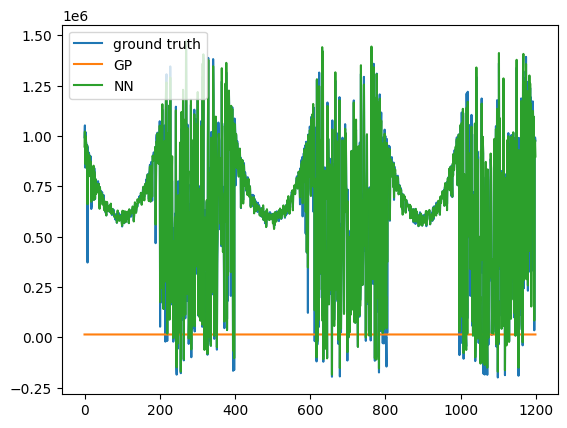

In [11]:
folder = r"C:\Users\yxu59\files\winter2026\park\simulation\PhysicalData_v3"
s1 = StreamClass(0, folder)

gpwrap = GPModelTorch.load("C:\\Users\\yxu59\\files\\autumn2025\\park\\codes\\plant simulation\\gpytorch_gp_model_revenue.pkl")
nnwrap = NNModelTorch.load("C:\\Users\\yxu59\\files\\autumn2025\\park\\codes\\plant simulation\\nn_model_revenue.pkl")

ys, gp_ys, nn_ys = [], [], []
for i in range(1200):
    Xb, yb, thb = s1.next(1)
    newx, newy, newth = torch.tensor(Xb), torch.tensor(yb), torch.tensor(thb)
    mean, std = gpwrap.predict(newx, newth, return_std=True)
    yhat = nnwrap.predict_single(Xb, thb)
    ys.append(newy.cpu().numpy().item())
    gp_ys.append(mean)
    nn_ys.append(yhat)

plt.plot(ys, label="ground truth")
plt.plot(gp_ys, label="GP")
plt.plot(nn_ys, label="NN")
plt.legend()

In [10]:
thb, newth

(array([11.5]), tensor([11.5000], dtype=torch.float64))

In [13]:
import os
import numpy as np
import torch

# 你工程里已经有这个函数的话就直接 import
from calib.online_calibrator import crps_gaussian  # 或你实际的路径

def theta_rmse(mu: np.ndarray, y: np.ndarray) -> float:
    mu = np.asarray(mu, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.sqrt(np.mean((mu - y) ** 2)))

import torch
import numpy as np
from calib.online_calibrator import crps_gaussian

def theta_crps_gaussian(mu: np.ndarray, var: np.ndarray, y: np.ndarray) -> float:
    mu = np.asarray(mu, dtype=float)
    var = np.asarray(var, dtype=float)
    y = np.asarray(y, dtype=float)

    var = np.maximum(var, 1e-12)

    crps_list = []
    for m, v, yt in zip(mu, var, y):
        m_t = torch.tensor(m, dtype=torch.float64)
        v_t = torch.tensor(v, dtype=torch.float64)
        y_t = torch.tensor(yt, dtype=torch.float64)
        crps_list.append(float(crps_gaussian(m_t, v_t, y_t).item()))
    return float(np.mean(crps_list))

def compute_metrics_for_file(pt_path: str, skip_first: int = 0):
    """
    pt_path: 例如 out_dir/plantSim_results_mode1.pt
    skip_first: 如果你认为第1个batch是warmup，可以跳过
    """
    obj = torch.load(pt_path, map_location="cpu")

    # obj 是 all_results: {"mode{m}_bs{bs}": results, ...}
    for exp_key, results in obj.items():
        print(f"\n=== {exp_key} ===")
        for method_name, r in results.items():
            mu = np.array(r["theta_hist"], dtype=float)
            var = np.array(r["theta_var_hist"], dtype=float)
            y = np.array(r["gt_theta_hist"], dtype=float)

            if skip_first > 0:
                mu = mu[skip_first:]
                var = var[skip_first:]
                y = y[skip_first:]

            rmse = theta_rmse(mu, y)
            crps = theta_crps_gaussian(mu, var, y)
            print(f"{method_name:>30s} | theta_RMSE={rmse:.3f} | theta_CRPS={crps:.3f}")


out_dir = r"figs/plantSim/v3_std"

# 你是按 mode 分开存的：plantSim_results_mode{mode}.pt
for mode in [0, 1, 2]:
    pt_path = os.path.join(out_dir, f"plantSim_results_mode{mode}.pt")
    if os.path.exists(pt_path):
        compute_metrics_for_file(pt_path, skip_first=1)  # 通常第1个batch可能没预测/没稳定
    else:
        print("Missing:", pt_path)


=== mode1_bs4 ===
                      BOCPD-PF | theta_RMSE=5.731 | theta_CRPS=3.598
     R-BOCPD-PF-usediscrepancy | theta_RMSE=5.570 | theta_CRPS=3.538
      R-BOCPD-PF-nodiscrepancy | theta_RMSE=0.534 | theta_CRPS=0.303

=== mode2_bs4 ===
                      BOCPD-PF | theta_RMSE=1.903 | theta_CRPS=1.107
     R-BOCPD-PF-usediscrepancy | theta_RMSE=1.629 | theta_CRPS=0.912
      R-BOCPD-PF-nodiscrepancy | theta_RMSE=1.074 | theta_CRPS=0.502

=== mode0_bs4 ===
                      BOCPD-PF | theta_RMSE=2.113 | theta_CRPS=1.240
     R-BOCPD-PF-usediscrepancy | theta_RMSE=2.103 | theta_CRPS=1.252
      R-BOCPD-PF-nodiscrepancy | theta_RMSE=0.939 | theta_CRPS=0.506

=== mode1_bs4 ===
                      BOCPD-PF | theta_RMSE=5.731 | theta_CRPS=3.598
     R-BOCPD-PF-usediscrepancy | theta_RMSE=5.570 | theta_CRPS=3.538
      R-BOCPD-PF-nodiscrepancy | theta_RMSE=0.534 | theta_CRPS=0.303

=== mode1_bs4 ===
                      BOCPD-PF | theta_RMSE=5.731 | theta_CRPS=3.598
     R-B

In [15]:
out_dir = r"figs/plantSim/v3"

# 你是按 mode 分开存的：plantSim_results_mode{mode}.pt
for mode in [0, 1, 2]:
    if mode == 0:
        pt_path = os.path.join(out_dir, f"plantSim_results.pt")
    else:
        pt_path = os.path.join(out_dir, f"plantSim_results_mode{mode}.pt")
    if os.path.exists(pt_path):
        compute_metrics_for_file(pt_path, skip_first=1)  # 通常第1个batch可能没预测/没稳定
    else:
        print("Missing:", pt_path)


=== mode0_bs4 ===
                      BOCPD-PF | theta_RMSE=1.432 | theta_CRPS=0.731
     R-BOCPD-PF-usediscrepancy | theta_RMSE=1.470 | theta_CRPS=0.768
      R-BOCPD-PF-nodiscrepancy | theta_RMSE=6.044 | theta_CRPS=3.766

=== mode1_bs4 ===
                      BOCPD-PF | theta_RMSE=1.161 | theta_CRPS=0.493
     R-BOCPD-PF-usediscrepancy | theta_RMSE=0.951 | theta_CRPS=0.427
      R-BOCPD-PF-nodiscrepancy | theta_RMSE=1.770 | theta_CRPS=0.928

=== mode2_bs4 ===
                      BOCPD-PF | theta_RMSE=1.629 | theta_CRPS=0.687
     R-BOCPD-PF-usediscrepancy | theta_RMSE=1.795 | theta_CRPS=0.814
      R-BOCPD-PF-nodiscrepancy | theta_RMSE=4.721 | theta_CRPS=2.980


In [16]:
import pandas as pd

# --- standardized metrics (from your earlier printout) ---
std = pd.DataFrame([
    {"Mode/Batch": "mode0_bs4", "Method": "BOCPD-PF",                    "theta_RMSE_std": 2.113, "theta_CRPS_std": 1.240},
    {"Mode/Batch": "mode0_bs4", "Method": "R-BOCPD-PF-usediscrepancy",   "theta_RMSE_std": 2.103, "theta_CRPS_std": 1.252},
    {"Mode/Batch": "mode0_bs4", "Method": "R-BOCPD-PF-nodiscrepancy",    "theta_RMSE_std": 0.939, "theta_CRPS_std": 0.506},

    {"Mode/Batch": "mode1_bs4", "Method": "BOCPD-PF",                    "theta_RMSE_std": 5.731, "theta_CRPS_std": 3.598},
    {"Mode/Batch": "mode1_bs4", "Method": "R-BOCPD-PF-usediscrepancy",   "theta_RMSE_std": 5.570, "theta_CRPS_std": 3.538},
    {"Mode/Batch": "mode1_bs4", "Method": "R-BOCPD-PF-nodiscrepancy",    "theta_RMSE_std": 0.534, "theta_CRPS_std": 0.303},

    {"Mode/Batch": "mode2_bs4", "Method": "BOCPD-PF",                    "theta_RMSE_std": 1.903, "theta_CRPS_std": 1.107},
    {"Mode/Batch": "mode2_bs4", "Method": "R-BOCPD-PF-usediscrepancy",   "theta_RMSE_std": 1.629, "theta_CRPS_std": 0.912},
    {"Mode/Batch": "mode2_bs4", "Method": "R-BOCPD-PF-nodiscrepancy",    "theta_RMSE_std": 1.074, "theta_CRPS_std": 0.502},
])

# --- non-standardized metrics (your latest printout) ---
raw = pd.DataFrame([
    {"Mode/Batch": "mode0_bs4", "Method": "BOCPD-PF",                    "theta_RMSE_raw": 1.432, "theta_CRPS_raw": 0.731},
    {"Mode/Batch": "mode0_bs4", "Method": "R-BOCPD-PF-usediscrepancy",   "theta_RMSE_raw": 1.470, "theta_CRPS_raw": 0.768},
    {"Mode/Batch": "mode0_bs4", "Method": "R-BOCPD-PF-nodiscrepancy",    "theta_RMSE_raw": 6.044, "theta_CRPS_raw": 3.766},

    {"Mode/Batch": "mode1_bs4", "Method": "BOCPD-PF",                    "theta_RMSE_raw": 1.161, "theta_CRPS_raw": 0.493},
    {"Mode/Batch": "mode1_bs4", "Method": "R-BOCPD-PF-usediscrepancy",   "theta_RMSE_raw": 0.951, "theta_CRPS_raw": 0.427},
    {"Mode/Batch": "mode1_bs4", "Method": "R-BOCPD-PF-nodiscrepancy",    "theta_RMSE_raw": 1.770, "theta_CRPS_raw": 0.928},

    {"Mode/Batch": "mode2_bs4", "Method": "BOCPD-PF",                    "theta_RMSE_raw": 1.629, "theta_CRPS_raw": 0.687},
    {"Mode/Batch": "mode2_bs4", "Method": "R-BOCPD-PF-usediscrepancy",   "theta_RMSE_raw": 1.795, "theta_CRPS_raw": 0.814},
    {"Mode/Batch": "mode2_bs4", "Method": "R-BOCPD-PF-nodiscrepancy",    "theta_RMSE_raw": 4.721, "theta_CRPS_raw": 2.980},
])

# --- merge into a 9x6 intermediate, then select 9x4 metrics only ---
df = std.merge(raw, on=["Mode/Batch", "Method"], how="inner")

# If you literally want 9x4 (metrics only), set a MultiIndex and keep 4 columns:
df_9x4 = (
    df.set_index(["Mode/Batch", "Method"])[
        ["theta_RMSE_std", "theta_CRPS_std", "theta_RMSE_raw", "theta_CRPS_raw"]
    ]
)

df_9x4

theta_RMSE_std  theta_CRPS_std  \
Mode/Batch Method                                                      
mode0_bs4  BOCPD-PF                            2.113           1.240   
           R-BOCPD-PF-usediscrepancy           2.103           1.252   
           R-BOCPD-PF-nodiscrepancy            0.939           0.506   
mode1_bs4  BOCPD-PF                            5.731           3.598   
           R-BOCPD-PF-usediscrepancy           5.570           3.538   
           R-BOCPD-PF-nodiscrepancy            0.534           0.303   
mode2_bs4  BOCPD-PF                            1.903           1.107   
           R-BOCPD-PF-usediscrepancy           1.629           0.912   
           R-BOCPD-PF-nodiscrepancy            1.074           0.502   

                                      theta_RMSE_raw  theta_CRPS_raw  
Mode/Batch Method                                                     
mode0_bs4  BOCPD-PF                            1.432           0.731  
           R-BOCPD-PF-usediscrepancy           1.470           0.768  
           R-BOCPD-PF-nodiscrepancy            6.044           3.766  
mode1_bs4  BOCPD-PF                            1.161           0.493  
           R-BOCPD-PF-usediscrepancy           0.951           0.427  
           R-BOCPD-PF-nodiscrepancy            1.770           0.928  
mode2_bs4  BOCPD-PF                            1.629           0.687  
           R-BOCPD-PF-usediscrepancy           1.795           0.814  
           R-BOCPD-PF-nodiscrepancy            4.721           2.980

In [20]:
import numpy as np

# df_9x4: index = ["Mode/Batch","Method"]
# columns = ["theta_RMSE_std","theta_CRPS_std","theta_RMSE_raw","theta_CRPS_raw"]

df_min_9x2 = df_9x4.copy()
df_min_9x2["theta_RMSE_min"] = df_min_9x2[["theta_RMSE_std", "theta_RMSE_raw"]].min(axis=1)
df_min_9x2["theta_CRPS_min"] = df_min_9x2[["theta_CRPS_std", "theta_CRPS_raw"]].min(axis=1)

# keep only 2 columns (9x2)
df_min_9x2 = df_min_9x2[["theta_RMSE_min", "theta_CRPS_min"]]

df_min_9x2

theta_RMSE_min  theta_CRPS_min
Mode/Batch Method                                                   
mode0_bs4  BOCPD-PF                            1.432           0.731
           R-BOCPD-PF-usediscrepancy           1.470           0.768
           R-BOCPD-PF-nodiscrepancy            0.939           0.506
mode1_bs4  BOCPD-PF                            1.161           0.493
           R-BOCPD-PF-usediscrepancy           0.951           0.427
           R-BOCPD-PF-nodiscrepancy            0.534           0.303
mode2_bs4  BOCPD-PF                            1.629           0.687
           R-BOCPD-PF-usediscrepancy           1.629           0.814
           R-BOCPD-PF-nodiscrepancy            1.074           0.502